# Import section

In [11]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer


from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import(RandomForestClassifier,
                    StackingClassifier,
                    GradientBoostingClassifier,
                    AdaBoostClassifier)

from xgboost import XGBClassifier

from sklearn.metrics import *

In [13]:
#to load it from a CSV file (change DATA_PATH to point to your dataset)

DATA_PATH = "customer_churn_dataset.csv"   # <-- just change this path

df = pd.read_csv(DATA_PATH)

X = df.drop("Churn", axis=1)
y = df["Churn"]

print("\nClass Distribution:")
print(y.value_counts())

print("\nClass Distribution with Names:")
print(
    pd.Series(
        y.map({0: "Retained", 1: "Churned"})
    ).value_counts()
)

print(f"\nThe number of samples: {X.shape[0]}")
print(f"The number of features: {X.shape[1]}")
print(f"The total number of columns including target: {df.shape[1]}")

print(f"\nFor the missing values\n {df.isnull().sum()}")
print(f"\nThe total missing values in all columns {df.isnull().sum().sum()}")



Class Distribution:
Churn
1    75
0    75
Name: count, dtype: int64

Class Distribution with Names:
Churn
Churned     75
Retained    75
Name: count, dtype: int64

The number of samples: 150
The number of features: 24
The total number of columns including target: 25

For the missing values
 monthly_income              0
savings_amount              0
credit_score                0
available_credit_limit      0
avg_session_minutes         0
weekly_logins               0
feature_click_count         0
app_open_count              0
satisfaction_rating         0
positive_review_score       0
recommend_likelihood        0
support_experience_score    0
account_age_months          0
total_purchases             0
loyalty_points              0
referral_count              0
device_type_score           0
browser_version_score       0
timezone_offset_score       0
screen_resolution_score     0
signup_channel_score        0
marketing_email_opens       0
page_load_time_score        0
weather_at_signup_

Explained Variance Ratio per PC: [0.18394332 0.17861691 0.14358733 0.13653356 0.05897211 0.04750386
 0.04512288 0.03906626 0.03695437 0.0357862  0.03378961 0.02627284
 0.00522415 0.00389389 0.00369617 0.00346863 0.00328601 0.00294335
 0.00246323 0.00228685 0.00218331 0.00160608 0.00143441 0.00136467]

Cummulative variance: [0.18394332 0.36256023 0.50614756 0.64268113 0.70165324 0.7491571
 0.79427998 0.83334623 0.87030061 0.9060868  0.93987641 0.96614925
 0.9713734  0.97526729 0.97896346 0.98243208 0.98571809 0.98866144
 0.99112467 0.99341153 0.99559484 0.99720092 0.99863533 1.        ]



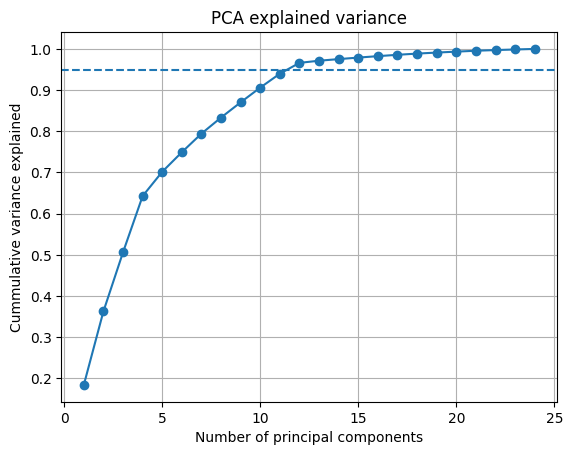

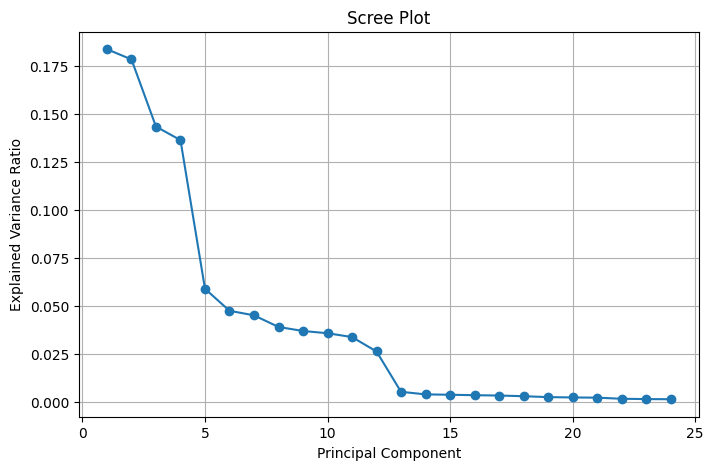


Components required for 95% variance is :12


In [14]:
X=df.drop('Churn',axis=1)
y=df['Churn']

#splitting the dataset into test and train

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


scalar=StandardScaler()

X_train_scaled=scalar.fit_transform(X_train)

pca=PCA()

X_train_pca=pca.fit_transform(X_train_scaled)


print("Explained Variance Ratio per PC:", pca.explained_variance_ratio_)

cummulative_variance=np.cumsum(pca.explained_variance_ratio_)

print(f"\nCummulative variance: {cummulative_variance}\n")

#scree plot for analysing how much var is retained as we keep more and more principal components

plt.plot(range(1,len(cummulative_variance)+1),cummulative_variance,marker='o')
plt.axhline(y=0.95,linestyle="--")
plt.xlabel("Number of principal components")
plt.ylabel("Cummulative variance explained")
plt.title("PCA explained variance")
plt.grid()

plt.show()


# Scree Plot

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()

plt.show()


#to find the no of components that are required to attain a var of 0.95

n_components=np.argmax(cummulative_variance>=0.95)+1

print(f"\nComponents required for 95% variance is :{n_components}")

In [15]:
# PCA Summary Table

pca_summary = pd.DataFrame({
    "Setting": ["With-PCA"],
    "Chosen Components": [n_components],
    "Variance Target": ["95%"],
    "Explained Variance (%)": [
        cummulative_variance[n_components - 1] * 100
    ],
    "Justification": [
        f"Reduce {X.shape[1]} original features (several highly correlated / redundant) to {n_components} components while retaining approximately 95% variance"
    ]
})

pca_summary

,Setting,Chosen Components,Variance Target,Explained Variance (%),Justification
0,With-PCA,12,95%,96.614925,Reduce 24 original features (several highly co...


## Creating 10 Models 


In [16]:
models ={

    "SVM":SVC(),

    "Naive Bayes":GaussianNB(),

    "KNN":KNeighborsClassifier(),

    "Logistic Regression":LogisticRegression(
        max_iter=5000),

    "Decision Tree":DecisionTreeClassifier(
        random_state=42),

    "Random Forest":RandomForestClassifier(
        random_state=42),

    "AdaBoost":AdaBoostClassifier(
        random_state=42),

    "Gradient Boosting":GradientBoostingClassifier(
        random_state=42),

    "XGBoost":XGBClassifier(
        random_state=42,
        eval_metric="logloss")
}

## create HyperParameter grids

In [17]:
param_grids = {

    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },

    "Naive Bayes": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },

    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__solver": ["liblinear"]
    },

    "Decision Tree": {
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10],
        "model__min_samples_split": [2, 5]
    },

    "AdaBoost": {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.5, 1.0]
    },

    "Gradient Boosting": {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },

    "XGBoost": {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },

}

In [18]:
#create a 5-fold cv

cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

#stratified attempts to maintain the class ratio in each fold


#NO_PCA PIPELINE

pipeline_no_pca=Pipeline([("scalar",StandardScaler()),
                          ("model",models["SVM"])])

#WITH_PCA_PIPELINE

pipeline_pca=Pipeline([('scalar',StandardScaler()),
                       ('PCA',PCA(n_components=0.95)),
                       ('model',models["SVM"])])

## one model first--SVM

In [19]:
#no pca

grid_no_pca=GridSearchCV(
    pipeline_no_pca,
    param_grids["SVM"],
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_no_pca.fit(X_train,y_train)

print("Best parameters: ")
print(grid_no_pca.best_params_)

print("Best CV score: ")
print(grid_no_pca.best_score_)


print("\nWith PCA\n")

#with pca

grid_pca=GridSearchCV(
    pipeline_pca,
    param_grids["SVM"],
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

grid_pca.fit(X_train,y_train)

print("Best parameters: ")
print(grid_pca.best_params_)

print("Best CV Score: ")
print(grid_pca.best_score_)

Best parameters: 
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV score: 
0.8682274247491637

With PCA

Best parameters: 
{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV Score: 
0.862529419051158


## Now for all the 10 models

In [20]:
def run_model(model_name,model,param_grid):

    print("\n"+"="*60)
    print(model_name)
    print("="*60)

    #no pca

    pipeline_no_pca=Pipeline([
    ("scalar",StandardScaler()),
    ("model",model)])

    grid_no_pca=GridSearchCV(
    pipeline_no_pca,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
    )

    grid_no_pca.fit(X_train,y_train)


    #with pca

    pipeline_pca=Pipeline([
    ("scalar",StandardScaler()),
    ("pca",PCA(n_components=0.95)),
    ("model",model)])


    grid_pca=GridSearchCV(
    pipeline_pca,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
    )

    grid_pca.fit(X_train,y_train)



    #testing the performance

    no_pca_predictions=grid_no_pca.best_estimator_.predict(X_test)
    pca_predictions=grid_pca.best_estimator_.predict(X_test)

    no_pca_accuracy=accuracy_score(
    y_test,
    no_pca_predictions)

    pca_accuracy=accuracy_score(
    y_test,
    pca_predictions)

    no_pca_f1=f1_score(
    y_test,
    no_pca_predictions)

    pca_f1=f1_score(
    y_test,
    pca_predictions)

    print("\nNo PCA")
    print("Best parameters:", grid_no_pca.best_params_)
    print("CV F1:", grid_no_pca.best_score_)
    print("Test Accuracy:", no_pca_accuracy)
    print("Test F1:", no_pca_f1)

    print("\nWith PCA")
    print("Best parameters:", grid_pca.best_params_)
    print("CV F1:", grid_pca.best_score_)
    print("Test Accuracy:", pca_accuracy)
    print("Test F1:", pca_f1)

    return {
        "No PCA": grid_no_pca,
        "With PCA": grid_pca
    }

    

In [35]:
results={}

for name,model in models.items():

    results[name]=run_model(
        name,
        model,
        param_grids[name]
    )




SVM

No PCA
Best parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
CV F1: 0.8682274247491637
Test Accuracy: 0.9
Test F1: 0.9090909090909091

With PCA
Best parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
CV F1: 0.862529419051158
Test Accuracy: 0.9
Test F1: 0.9090909090909091

Naive Bayes

No PCA
Best parameters: {'model__var_smoothing': 1e-09}
CV F1: 0.8346376811594203
Test Accuracy: 0.8666666666666667
Test F1: 0.875

With PCA
Best parameters: {'model__var_smoothing': 1e-09}
CV F1: 0.8111458171458171
Test Accuracy: 0.9
Test F1: 0.9032258064516129

KNN

No PCA
Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'uniform'}
CV F1: 0.8116206756206756
Test Accuracy: 0.8666666666666667
Test F1: 0.8823529411764706

With PCA
Best parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}
CV F1: 0.8098827838827839
Test Accuracy: 0.8666666666666667
Test F1: 0.8


No PCA
Best parameters: {'model__var_smoothing': 1e-09}
CV F1: 0.8346376811594203
Test Accuracy: 0.8666666666666667
Test F1: 0.875

With PCA
Best parameters: {'model__var_smoothing': 1e-09}
CV F1: 0.8111458171458171
Test Accuracy: 0.9
Test F1: 0.9032258064516129

KNN



No PCA
Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 5, 'model__weights': 'uniform'}
CV F1: 0.8116206756206756
Test Accuracy: 0.8666666666666667
Test F1: 0.8823529411764706

With PCA
Best parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}
CV F1: 0.8098827838827839
Test Accuracy: 0.8666666666666667
Test F1: 0.875

Logistic Regression



No PCA
Best parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}
CV F1: 0.8469686834904226
Test Accuracy: 0.9
Test F1: 0.9032258064516129

With PCA
Best parameters: {'model__C': 0.1, 'model__solver': 'liblinear'}
CV F1: 0.8539420289855073
Test Accuracy: 0.9
Test F1: 0.9032258064516129

Decision Tree



No PCA
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2}
CV F1: 0.7768831168831168
Test Accuracy: 0.7333333333333333
Test F1: 0.7647058823529411

With PCA
Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 5}
CV F1: 0.7356521739130434
Test Accuracy: 0.8333333333333334
Test F1: 0.8387096774193549

Random Forest



No PCA
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
CV F1: 0.8489610389610389
Test Accuracy: 0.8333333333333334
Test F1: 0.8571428571428571

With PCA
Best parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
CV F1: 0.8199420289855072
Test Accuracy: 0.8666666666666667
Test F1: 0.8823529411764706

AdaBoost



No PCA
Best parameters: {'model__learning_rate': 1.0, 'model__n_estimators': 50}
CV F1: 0.8563768115942029
Test Accuracy: 0.8
Test F1: 0.8125

With PCA
Best parameters: {'model__learning_rate': 1.0, 'model__n_estimators': 50}
CV F1: 0.8300076445293836
Test Accuracy: 0.8666666666666667
Test F1: 0.875

Gradient Boosting



No PCA
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}
CV F1: 0.8504927536231884
Test Accuracy: 0.8333333333333334
Test F1: 0.8571428571428571

With PCA
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 50}
CV F1: 0.823727576771055
Test Accuracy: 0.8333333333333334
Test F1: 0.8484848484848485

XGBoost



No PCA
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
CV F1: 0.8598095238095238
Test Accuracy: 0.7666666666666667
Test F1: 0.8

With PCA
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
CV F1: 0.8207915273132664
Test Accuracy: 0.8666666666666667
Test F1: 0.8823529411764706
{'SVM': {'No PCA': GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scalar', StandardScaler()),
                                       ('model', SVC())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__gamma': ['scale', 'auto'],
                         'model__kernel': ['linear', 'rbf']},
             scoring='f1'), 'With PCA': GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scalar', StandardScaler()),
                    

## for stacking

In [22]:
base_learners=[
    ("svm",SVC(
        C=1,
        kernel="rbf",
        probability=True)),
    ("knn",KNeighborsClassifier(
        n_neighbors=5)),
    ("tree",DecisionTreeClassifier(
        max_depth=5,
        random_state=42))]


stacking_model=StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(
        max_iter=5000))


stacking_grid={
    "model__final_estimator__C":[0.1,
                                 1,
                                 10
                                ]
}

results["Stacking"] = run_model(
    "Stacking",
    stacking_model,
    stacking_grid
)


Stacking

No PCA
Best parameters: {'model__final_estimator__C': 0.1}
CV F1: 0.8623678929765886
Test Accuracy: 0.8666666666666667
Test F1: 0.8823529411764706

With PCA
Best parameters: {'model__final_estimator__C': 10}
CV F1: 0.8510355731225298
Test Accuracy: 0.9
Test F1: 0.9032258064516129



No PCA
Best parameters: {'model__final_estimator__C': 0.1}
CV F1: 0.8558461538461538
Test Accuracy: 0.8333333333333334
Test F1: 0.8484848484848485

With PCA
Best parameters: {'model__final_estimator__C': 10}
CV F1: 0.8510355731225298
Test Accuracy: 0.9
Test F1: 0.9032258064516129


In [23]:
# Hyperparameter Tuning Summary

tuning_summary = []

for model_name, model_results in results.items():

    no_pca = model_results["No PCA"]
    pca = model_results["With PCA"]

    tuning_summary.append({
        "Model": model_name,
        "Best Parameters (No PCA)": no_pca.best_params_,
        "Best CV F1 (No PCA)": no_pca.best_score_,
        "Best Parameters (With PCA)": pca.best_params_,
        "Best CV F1 (With PCA)": pca.best_score_
    })

tuning_df = pd.DataFrame(tuning_summary)

tuning_df

,Model,Best Parameters (No PCA),Best CV F1 (No PCA),Best Parameters (With PCA),Best CV F1 (With PCA)
0,SVM,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.868227,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.862529
1,Naive Bayes,{'model__var_smoothing': 1e-09},0.834638,{'model__var_smoothing': 1e-09},0.811146
2,KNN,"{'model__metric': 'manhattan', 'model__n_neigh...",0.811621,"{'model__metric': 'euclidean', 'model__n_neigh...",0.809883
3,Logistic Regression,"{'model__C': 0.1, 'model__solver': 'liblinear'}",0.846969,"{'model__C': 0.1, 'model__solver': 'liblinear'}",0.853942
4,Decision Tree,"{'model__max_depth': None, 'model__min_samples...",0.776883,"{'model__max_depth': 5, 'model__min_samples_sp...",0.735652
5,Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.848961,"{'model__max_depth': None, 'model__min_samples...",0.819942
6,AdaBoost,"{'model__learning_rate': 1.0, 'model__n_estima...",0.856377,"{'model__learning_rate': 1.0, 'model__n_estima...",0.830008
7,Gradient Boosting,"{'model__learning_rate': 0.1, 'model__max_dept...",0.850493,"{'model__learning_rate': 0.1, 'model__max_dept...",0.823728
8,XGBoost,"{'model__learning_rate': 0.1, 'model__max_dept...",0.859810,"{'model__learning_rate': 0.1, 'model__max_dept...",0.820792
9,Stacking,{'model__final_estimator__C': 0.1},0.862368,{'model__final_estimator__C': 10},0.851036


In [24]:
fold_results = []

for model_name, model_results in results.items():

    no_pca_grid = model_results["No PCA"]
    pca_grid = model_results["With PCA"]

    no_pca_index = no_pca_grid.best_index_
    pca_index = pca_grid.best_index_

    no_pca_folds = [
        no_pca_grid.cv_results_[f"split{i}_test_score"][no_pca_index]
        for i in range(5)
    ]

    pca_folds = [
        pca_grid.cv_results_[f"split{i}_test_score"][pca_index]
        for i in range(5)
    ]

    fold_results.append({
        "Model": model_name,
        "Setting": "No-PCA",
        "Fold 1": no_pca_folds[0],
        "Fold 2": no_pca_folds[1],
        "Fold 3": no_pca_folds[2],
        "Fold 4": no_pca_folds[3],
        "Fold 5": no_pca_folds[4],
        "Average": np.mean(no_pca_folds)
    })

    fold_results.append({
        "Model": model_name,
        "Setting": "With-PCA",
        "Fold 1": pca_folds[0],
        "Fold 2": pca_folds[1],
        "Fold 3": pca_folds[2],
        "Fold 4": pca_folds[3],
        "Fold 5": pca_folds[4],
        "Average": np.mean(pca_folds)
    })

fold_df = pd.DataFrame(fold_results)

fold_df

,Model,Setting,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,SVM,No-PCA,1.000000,0.769231,0.769231,0.956522,0.846154,0.868227
1,SVM,With-PCA,1.000000,0.769231,0.740741,0.956522,0.846154,0.862529
2,Naive Bayes,No-PCA,1.000000,0.750000,0.666667,0.956522,0.800000,0.834638
3,Naive Bayes,With-PCA,0.916667,0.740741,0.720000,0.909091,0.769231,0.811146
4,KNN,No-PCA,0.923077,0.740741,0.800000,0.880000,0.714286,0.811621
5,KNN,With-PCA,0.916667,0.714286,0.769231,0.880000,0.769231,0.809883
6,Logistic Regression,No-PCA,0.956522,0.769231,0.720000,0.909091,0.880000,0.846969
7,Logistic Regression,With-PCA,0.956522,0.720000,0.720000,0.956522,0.916667,0.853942
8,Decision Tree,No-PCA,0.857143,0.727273,0.800000,0.833333,0.666667,0.776883
9,Decision Tree,With-PCA,0.833333,0.700000,0.666667,0.782609,0.695652,0.735652


In [25]:
comparison = []

for model_name, model_results in results.items():

    no_pca_model = model_results["No PCA"]
    pca_model = model_results["With PCA"]

    no_pca_pred = no_pca_model.best_estimator_.predict(X_test)
    pca_pred = pca_model.best_estimator_.predict(X_test)

    comparison.append({

        "Model": model_name,

        "Accuracy No PCA":
            accuracy_score(y_test, no_pca_pred),

        "Accuracy PCA":
            accuracy_score(y_test, pca_pred),

        "F1 No PCA":
            f1_score(y_test, no_pca_pred),

        "F1 PCA":
            f1_score(y_test, pca_pred),

        "CV F1 No PCA":
            no_pca_model.best_score_,

        "CV F1 PCA":
            pca_model.best_score_
    })

comparison_df = pd.DataFrame(comparison)

comparison_df["Accuracy Change"] = (
    comparison_df["Accuracy PCA"]
    -
    comparison_df["Accuracy No PCA"]
)

comparison_df["F1 Change"] = (
    comparison_df["F1 PCA"]
    -
    comparison_df["F1 No PCA"]
)


comparison_df

,Model,Accuracy No PCA,Accuracy PCA,F1 No PCA,F1 PCA,CV F1 No PCA,CV F1 PCA,Accuracy Change,F1 Change
0,SVM,0.900000,0.900000,0.909091,0.909091,0.868227,0.862529,0.000000,0.000000
1,Naive Bayes,0.866667,0.900000,0.875000,0.903226,0.834638,0.811146,0.033333,0.028226
2,KNN,0.866667,0.866667,0.882353,0.875000,0.811621,0.809883,0.000000,-0.007353
3,Logistic Regression,0.900000,0.900000,0.903226,0.903226,0.846969,0.853942,0.000000,0.000000
4,Decision Tree,0.733333,0.833333,0.764706,0.838710,0.776883,0.735652,0.100000,0.074004
5,Random Forest,0.833333,0.866667,0.857143,0.882353,0.848961,0.819942,0.033333,0.025210
6,AdaBoost,0.800000,0.866667,0.812500,0.875000,0.856377,0.830008,0.066667,0.062500
7,Gradient Boosting,0.833333,0.833333,0.857143,0.848485,0.850493,0.823728,0.000000,-0.008658
8,XGBoost,0.766667,0.866667,0.800000,0.882353,0.859810,0.820792,0.100000,0.082353
9,Stacking,0.866667,0.900000,0.882353,0.903226,0.862368,0.851036,0.033333,0.020873


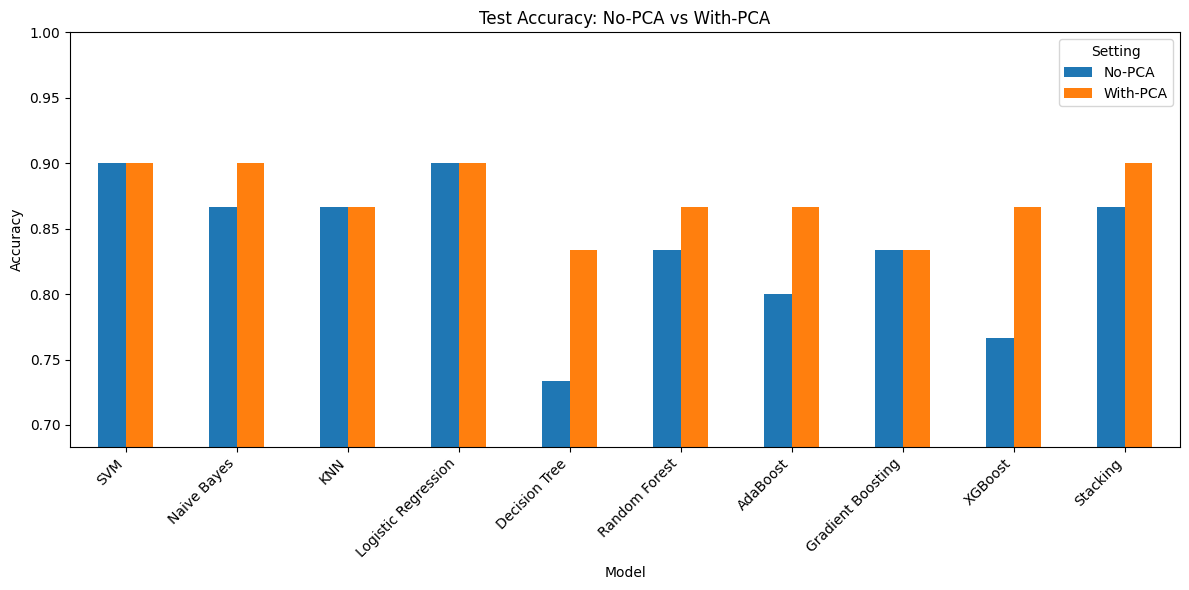

In [26]:
# Test Accuracy: No-PCA vs With-PCA

accuracy_plot = comparison_df.set_index("Model")[
    ["Accuracy No PCA", "Accuracy PCA"]
]

accuracy_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Test Accuracy: No-PCA vs With-PCA")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(max(0, accuracy_plot.values.min() - 0.05), 1.00)
plt.xticks(rotation=45, ha="right")
plt.legend(
    ["No-PCA", "With-PCA"],
    title="Setting"
)

plt.tight_layout()
plt.show()

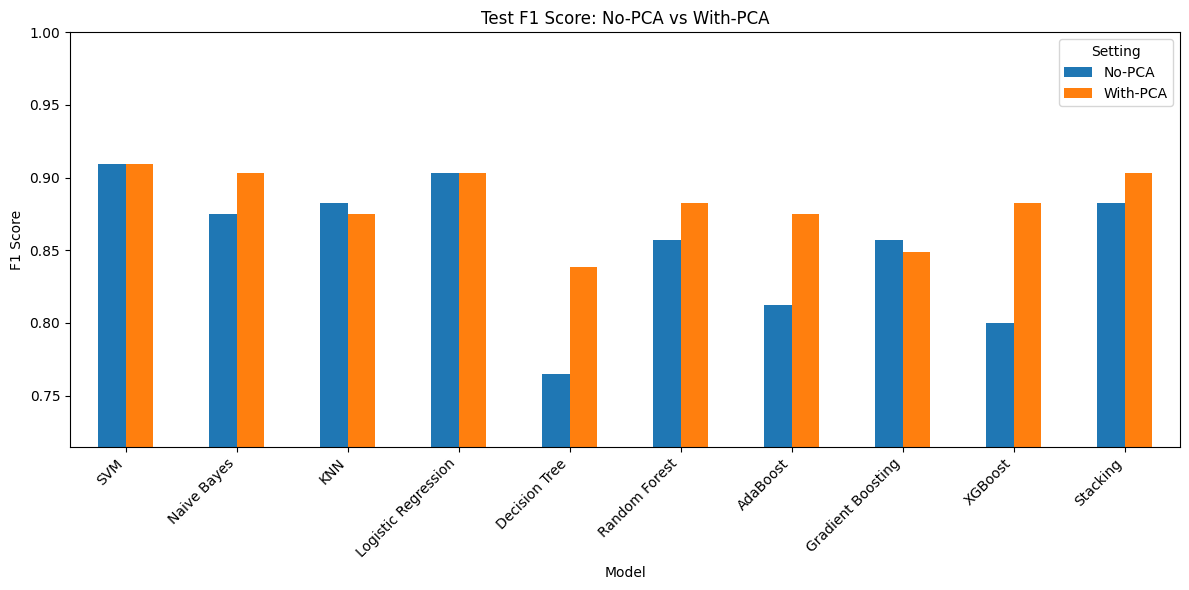

In [27]:
# Test F1 Score: No-PCA vs With-PCA

f1_plot = comparison_df.set_index("Model")[
    ["F1 No PCA", "F1 PCA"]
]

f1_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Test F1 Score: No-PCA vs With-PCA")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(max(0, f1_plot.values.min() - 0.05), 1.00)
plt.xticks(rotation=45, ha="right")
plt.legend(
    ["No-PCA", "With-PCA"],
    title="Setting"
)

plt.tight_layout()
plt.show()

In [28]:
stability_results = []

for model_name, model_results in results.items():

    no_pca_grid = model_results["No PCA"]
    pca_grid = model_results["With PCA"]

    no_pca_index = no_pca_grid.best_index_
    pca_index = pca_grid.best_index_

    no_pca_folds = [
        no_pca_grid.cv_results_[f"split{i}_test_score"][no_pca_index]
        for i in range(5)
    ]

    pca_folds = [
        pca_grid.cv_results_[f"split{i}_test_score"][pca_index]
        for i in range(5)
    ]

    stability_results.append({

        "Model": model_name,

        "No PCA Std":
            np.std(no_pca_folds),

        "PCA Std":
            np.std(pca_folds)
    })

    

stability_df = pd.DataFrame(stability_results)

stability_df["More Stable"] = np.where(
    stability_df["PCA Std"] < stability_df["No PCA Std"],
    "With PCA",
    "No PCA"
    )

stability_df

#PCA produced more stable performance across the five folds
#because the standard deviation decreased

,Model,No PCA Std,PCA Std,More Stable
0,SVM,0.095129,0.101526,No PCA
1,Naive Bayes,0.125521,0.084557,With PCA
2,KNN,0.079663,0.075846,With PCA
3,Logistic Regression,0.088449,0.110327,No PCA
4,Decision Tree,0.070387,0.062252,With PCA
5,Random Forest,0.054482,0.119321,No PCA
6,AdaBoost,0.103390,0.106198,No PCA
7,Gradient Boosting,0.029807,0.121579,No PCA
8,XGBoost,0.056463,0.099438,No PCA
9,Stacking,0.068894,0.083206,No PCA


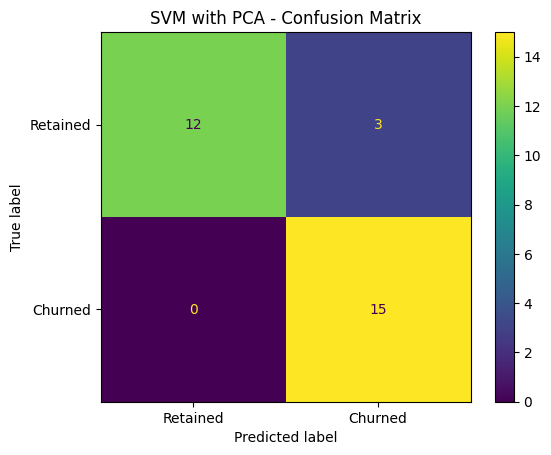

In [29]:
best_svm = results["SVM"]["With PCA"]

y_pred = best_svm.best_estimator_.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Churned"]
)

disp.plot()

plt.title("SVM with PCA - Confusion Matrix")

plt.show()

## Confusion matrix no pca

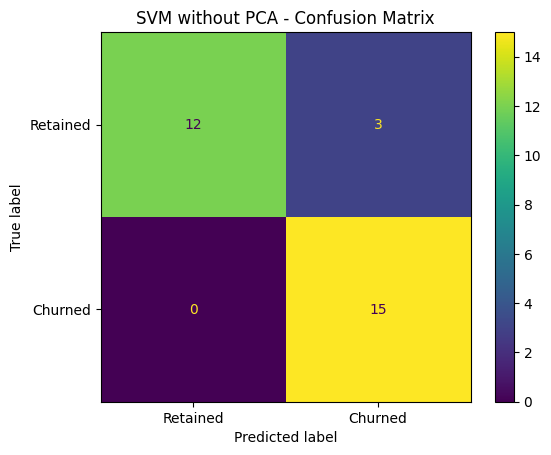

In [30]:
best_svm = results["SVM"]["No PCA"]

y_pred = best_svm.best_estimator_.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Retained", "Churned"]
)

disp.plot()

plt.title("SVM without PCA - Confusion Matrix")

plt.show()

## ROC -Curve

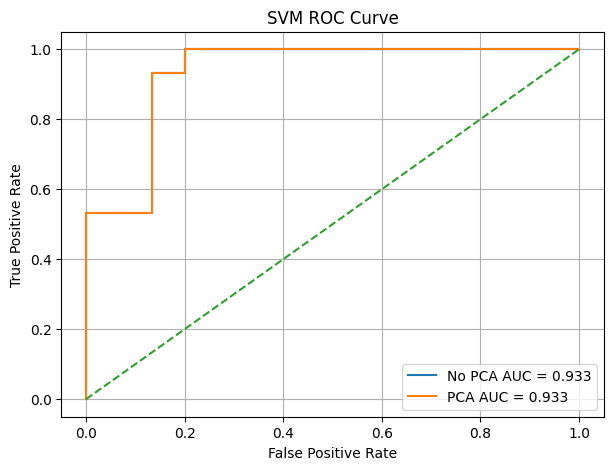

In [31]:
model_no_pca = results["SVM"]["No PCA"].best_estimator_
model_pca = results["SVM"]["With PCA"].best_estimator_

score_no_pca = model_no_pca.decision_function(X_test)
score_pca = model_pca.decision_function(X_test)

fpr_no, tpr_no, _ = roc_curve(
    y_test,
    score_no_pca
)

fpr_pca, tpr_pca, _ = roc_curve(
    y_test,
    score_pca
)

auc_no = auc(fpr_no, tpr_no)
auc_pca = auc(fpr_pca, tpr_pca)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_no,
    tpr_no,
    label=f"No PCA AUC = {auc_no:.3f}"
)

plt.plot(
    fpr_pca,
    tpr_pca,
    label=f"PCA AUC = {auc_pca:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("SVM ROC Curve")

plt.legend()

plt.grid()

plt.show()

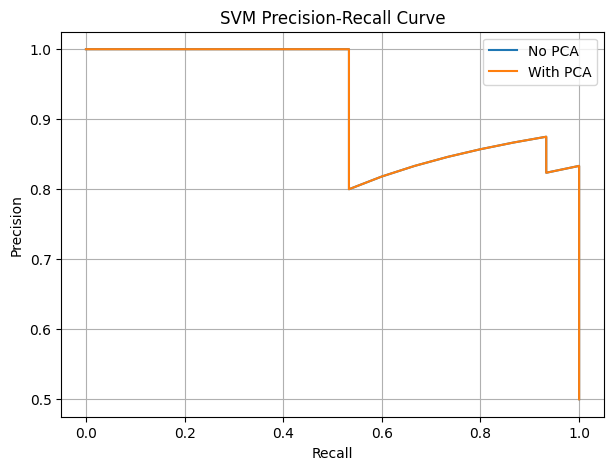

In [32]:
precision_no, recall_no, _ = precision_recall_curve(
    y_test,
    score_no_pca
)

precision_pca, recall_pca, _ = precision_recall_curve(
    y_test,
    score_pca
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_no,
    precision_no,
    label="No PCA"
)

plt.plot(
    recall_pca,
    precision_pca,
    label="With PCA"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("SVM Precision-Recall Curve")

plt.legend()

plt.grid()

plt.show()

# Classification Report — SVM Without PCA

In [33]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Retained", "Churned"]
    )
)

              precision    recall  f1-score   support

    Retained       1.00      0.80      0.89        15
     Churned       0.83      1.00      0.91        15

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



In [34]:
# Best models based on test F1-score

best_models = comparison_df.sort_values(
    by="F1 No PCA",
    ascending=False
)

best_models[
    [
        "Model",
        "F1 No PCA",
        "F1 PCA",
        "CV F1 No PCA",
        "CV F1 PCA"
    ]

]

# Best model with PCA

comparison_df.sort_values(
    by="F1 PCA",
    ascending=False
)[
    [
        "Model",
        "F1 PCA",
        "CV F1 PCA"
    ]
].head()

,Model,F1 PCA,CV F1 PCA
0,SVM,0.909091,0.862529
1,Naive Bayes,0.903226,0.811146
3,Logistic Regression,0.903226,0.853942
9,Stacking,0.903226,0.851036
5,Random Forest,0.882353,0.819942


## Observation Questions

### 1. Which models improved most with PCA? Which did not? Why?

PCA improved the performance of **Naive Bayes, Decision Tree, Random Forest, AdaBoost, XGBoost, and Stacking** on the test set. The largest improvement was observed in **XGBoost**, where the F1-score increased from **0.8000 to 0.8824**. Decision Tree also improved significantly, from **0.7647 to 0.8387**.

**KNN** and **Gradient Boosting** showed a small decrease after PCA. **SVM** and **Logistic Regression** had almost no change in their test F1-score.

PCA does not always improve every model because dimensionality reduction can remove some information that may be useful for a particular algorithm.

---

### 2. Did PCA reduce variance across folds (more stable results)?

PCA did **not consistently reduce the variation across the five folds**. Some models showed more consistent fold results after PCA, while others still had noticeable differences between folds.

Therefore, based on the cross-validation results, PCA cannot be concluded to have made **all models more stable**. Its main benefit in this experiment was improved test performance for several models rather than consistently reducing fold-to-fold variation.

---

### 3. For high-dimensional data, was PCA beneficial in reducing overfitting?

Yes, PCA can help reduce overfitting by reducing the number of input dimensions and removing redundant information. In this experiment, some models, particularly **Decision Tree, XGBoost, AdaBoost, Random Forest, and Stacking**, showed better test performance after PCA.

This suggests that reducing the feature space helped some models generalize better to the test data. However, PCA did not reduce overfitting equally for every model.

---

### 4. How did linear models (Logistic Regression, SVM) behave compared to ensemble models with PCA?

The linear models were already performing well without PCA, so PCA produced only a small change.

- **SVM:** F1 remained **0.9091 → 0.9091**
- **Logistic Regression:** F1 remained **0.9032 → 0.9032**

In comparison, several ensemble models benefited more from PCA. For example:

- **XGBoost:** 0.8000 → 0.8824
- **AdaBoost:** 0.8125 → 0.8750
- **Random Forest:** 0.8571 → 0.8824
- **Stacking:** 0.8485 → 0.9032

Therefore, PCA had a more noticeable effect on several ensemble models than on the linear models.

---

### 5. Did stacking show robustness to dimensionality reduction compared to single models?

Yes. **Stacking showed good robustness to PCA.** Its test F1-score increased from **0.8485 without PCA to 0.9032 with PCA**, and its accuracy increased from **0.8333 to 0.9000**.

Although its cross-validation F1 changed only slightly (**0.8558 → 0.8510**), its test performance remained strong after dimensionality reduction.

This suggests that the combination of multiple base learners in the stacking model made it relatively robust to the reduced feature space.